# Klasterovanje prodavaca

Cilj ovog notebooka je segmentacija prodavaca na Olist platformi. Za razliku od prethodnog dela, gde su analizirani kupci, ovde se posmatraju karakteristike prodavaca: obim prodaje, prihod, broj kupaca, raznovrsnost proizvoda, ocene i performanse isporuke.

U ovom delu koriste se dva algoritma za klasterovanje:

- Agglomerative Clustering, kao hijerarhijski pristup,
- Gaussian Mixture Model (GMM), kao probabilisticki pristup.

Na kraju se modeli porede preko metrika i poslovne interpretacije, a finalni klasteri se analiziraju kroz originalne vrednosti atributa.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from scipy.cluster.hierarchy import linkage, dendrogram

## Ucitavanje podataka

Ucitava se tabela `seller_master`, koja je formirana u prethodnom notebooku. Ona sadrzi objedinjene informacije o prodavcima, njihovim porudzbinama, prihodima, ocenama, kasnjenjima i kategorijama proizvoda.

Ukoliko se notebook pokrece iz standardne strukture projekta, koristi se putanja `../data/processed/seller_master.csv`. Druga putanja je dodata samo kao rezervna opcija za lakse testiranje.

In [2]:
try:
    seller_master = pd.read_csv("../data/processed/seller_master.csv")
except FileNotFoundError:
    seller_master = pd.read_csv("seller_master.csv")

seller_master.head()

,seller_id,seller_order_count,seller_items_sold,seller_unique_customers,seller_total_revenue,seller_total_freight_value,seller_avg_item_price,seller_avg_freight_value,seller_avg_review_score,seller_avg_delivery_days,seller_avg_delay_days,seller_delayed_order_rate,seller_unique_products,seller_unique_categories,seller_state,seller_top_category,seller_active_days
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3,3,2685.00,63.06,895.000000,21.020000,3.666667,10.333333,-16.333333,0.000000,1,1,SP,small_appliances,21
1,001cca7ae9ae17fb1caed9dfb1094831,200,239,200,25080.03,8854.14,104.937364,37.046611,3.902542,12.628205,-13.213675,0.050209,11,2,ES,garden_tools,523
2,001e6ad469a905060d959994f1b41e4f,1,1,1,250.00,17.94,250.000000,17.940000,1.000000,10.691851,-12.000000,0.000000,1,1,RJ,sports_leisure,0
3,002100f778ceb8431b7a1020ff7ab48f,51,55,51,1234.50,793.66,22.445455,14.430182,3.981818,15.777778,-8.185185,0.163636,24,1,SP,furniture_decor,210
4,003554e2dce176b5555353e4f3555ac8,1,1,1,120.00,19.38,120.000000,19.380000,5.000000,4.000000,-27.000000,0.000000,1,1,GO,unknown,0


In [3]:
seller_master.shape

(3095, 17)

## Provera nedostajucih vrednosti

Pre klasterovanja proverava se da li postoje nedostajuce vrednosti. Ovo je vazno zato sto algoritmi klasterovanja ne mogu direktno da rade sa `NaN` vrednostima.

Ako se pojave nedostajuce vrednosti u numerickim atributima, popunjavaju se medijanom. Za kategoricke atribute koristi se vrednost `unknown`.

In [4]:
seller_master = seller_master.copy()

numeric_cols_all = seller_master.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols_all = seller_master.select_dtypes(include=["object"]).columns.tolist()

for col in numeric_cols_all:
    seller_master[col] = seller_master[col].fillna(seller_master[col].median())

for col in categorical_cols_all:
    seller_master[col] = seller_master[col].fillna("unknown")

seller_master.isna().sum().sum()

np.int64(0)

## Izbor atributa za klasterovanje

Za klasterovanje se koriste samo numericki atributi koji opisuju ponasanje i performanse prodavaca.

Identifikator prodavca i kategoricki atributi, kao sto su drzava prodavca i dominantna kategorija, ne koriste se direktno u treniranju modela. Oni se cuvaju za kasniju interpretaciju klastera.

In [5]:
id_cols = ["seller_id"]

categorical_descriptor_cols = [
    col for col in ["seller_state", "seller_top_category", "dominant_category"]
    if col in seller_master.columns
]

feature_cols = [
    col for col in seller_master.select_dtypes(include=["int64", "float64"]).columns
    if col not in id_cols
]

X_original = seller_master[feature_cols].copy()

X_original.head()

,seller_order_count,seller_items_sold,seller_unique_customers,seller_total_revenue,seller_total_freight_value,seller_avg_item_price,seller_avg_freight_value,seller_avg_review_score,seller_avg_delivery_days,seller_avg_delay_days,seller_delayed_order_rate,seller_unique_products,seller_unique_categories,seller_active_days
0,3,3,3,2685.00,63.06,895.000000,21.020000,3.666667,10.333333,-16.333333,0.000000,1,1,21
1,200,239,200,25080.03,8854.14,104.937364,37.046611,3.902542,12.628205,-13.213675,0.050209,11,2,523
2,1,1,1,250.00,17.94,250.000000,17.940000,1.000000,10.691851,-12.000000,0.000000,1,1,0
3,51,55,51,1234.50,793.66,22.445455,14.430182,3.981818,15.777778,-8.185185,0.163636,24,1,210
4,1,1,1,120.00,19.38,120.000000,19.380000,5.000000,4.000000,-27.000000,0.000000,1,1,0


In [6]:
X_original.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
seller_order_count,3095.0,32.31,105.14,1.00,2.00,6.00,21.50,1854.00
seller_items_sold,3095.0,36.40,119.19,1.00,2.00,8.00,24.00,2033.00
seller_unique_customers,3095.0,32.00,103.77,1.00,2.00,6.00,21.00,1824.00
seller_total_revenue,3095.0,4391.48,13922.00,3.50,208.85,821.48,3280.83,229472.63
seller_total_freight_value,3095.0,727.60,2327.16,6.66,46.17,155.52,558.17,51612.55
seller_avg_item_price,3095.0,176.33,322.15,3.50,52.18,95.47,173.99,6729.00
seller_avg_freight_value,3095.0,23.38,18.96,1.20,14.74,18.23,24.37,308.34
seller_avg_review_score,3095.0,3.97,0.97,1.00,3.71,4.17,4.60,5.00
seller_avg_delivery_days,3095.0,11.66,6.97,1.00,8.00,10.69,13.61,189.00
seller_avg_delay_days,3095.0,-12.28,7.84,-66.00,-15.22,-12.00,-9.20,167.00


## Analiza asimetrije atributa

Atributi vezani za prodaju i prihod kod e-commerce podataka najcesce imaju izrazenu desnu asimetriju. To znaci da vecina prodavaca ima mali broj porudzbina i manji prihod, dok mali broj prodavaca ostvaruje veoma velike vrednosti.

Zbog toga se za izrazito asimetricne nenegativne atribute primenjuje `log1p` transformacija. Ova transformacija smanjuje uticaj ekstremnih vrednosti, ali ne menja redosled prodavaca po velicini atributa.

In [7]:
skewness = (
    X_original
    .skew()
    .sort_values(ascending=False)
)

skewness.round(2)

seller_total_freight_value    10.55
seller_items_sold              9.79
seller_order_count             9.64
seller_unique_customers        9.61
seller_total_revenue           9.05
seller_avg_item_price          8.71
seller_avg_delivery_days       7.36
seller_unique_products         6.64
seller_avg_freight_value       5.23
seller_delayed_order_rate      4.41
seller_unique_categories       3.87
seller_avg_delay_days          3.67
seller_active_days             0.98
seller_avg_review_score       -1.55
dtype: float64

In [8]:
log_cols = [
    col for col in X_original.columns
    if (
        X_original[col].min() >= 0
        and abs(X_original[col].skew()) > 1.5
        and col != "seller_avg_review_score"
    )
]

log_cols

['seller_order_count',
 'seller_items_sold',
 'seller_unique_customers',
 'seller_total_revenue',
 'seller_total_freight_value',
 'seller_avg_item_price',
 'seller_avg_freight_value',
 'seller_avg_delivery_days',
 'seller_delayed_order_rate',
 'seller_unique_products',
 'seller_unique_categories']

In [9]:
X_model = X_original.copy()

X_model[log_cols] = np.log1p(X_model[log_cols])

X_model.head()

,seller_order_count,seller_items_sold,seller_unique_customers,seller_total_revenue,seller_total_freight_value,seller_avg_item_price,seller_avg_freight_value,seller_avg_review_score,seller_avg_delivery_days,seller_avg_delay_days,seller_delayed_order_rate,seller_unique_products,seller_unique_categories,seller_active_days
0,1.386294,1.386294,1.386294,7.895808,4.159820,6.797940,3.091951,3.666667,2.427748,-16.333333,0.000000,0.693147,0.693147,21
1,5.303305,5.480639,5.303305,10.129867,9.088753,4.662848,3.638812,3.902542,2.612142,-13.213675,0.048989,2.484907,1.098612,523
2,0.693147,0.693147,0.693147,5.525453,2.941276,5.525453,2.941276,1.000000,2.458892,-12.000000,0.000000,0.693147,0.693147,0
3,3.951244,4.025352,3.951244,7.119231,6.677914,3.154677,2.736325,3.981818,2.820055,-8.185185,0.151550,3.218876,0.693147,210
4,0.693147,0.693147,0.693147,4.795791,3.014554,4.795791,3.014554,5.000000,1.609438,-27.000000,0.000000,0.693147,0.693147,0


## Distribucije nakon pripreme

Na histogramima se proverava oblik distribucija nakon log transformacije. Cilj nije da svi atributi postanu savrseno normalno rasporedjeni, vec da se smanji dominacija ekstremnih prodavaca u prostoru atributa.

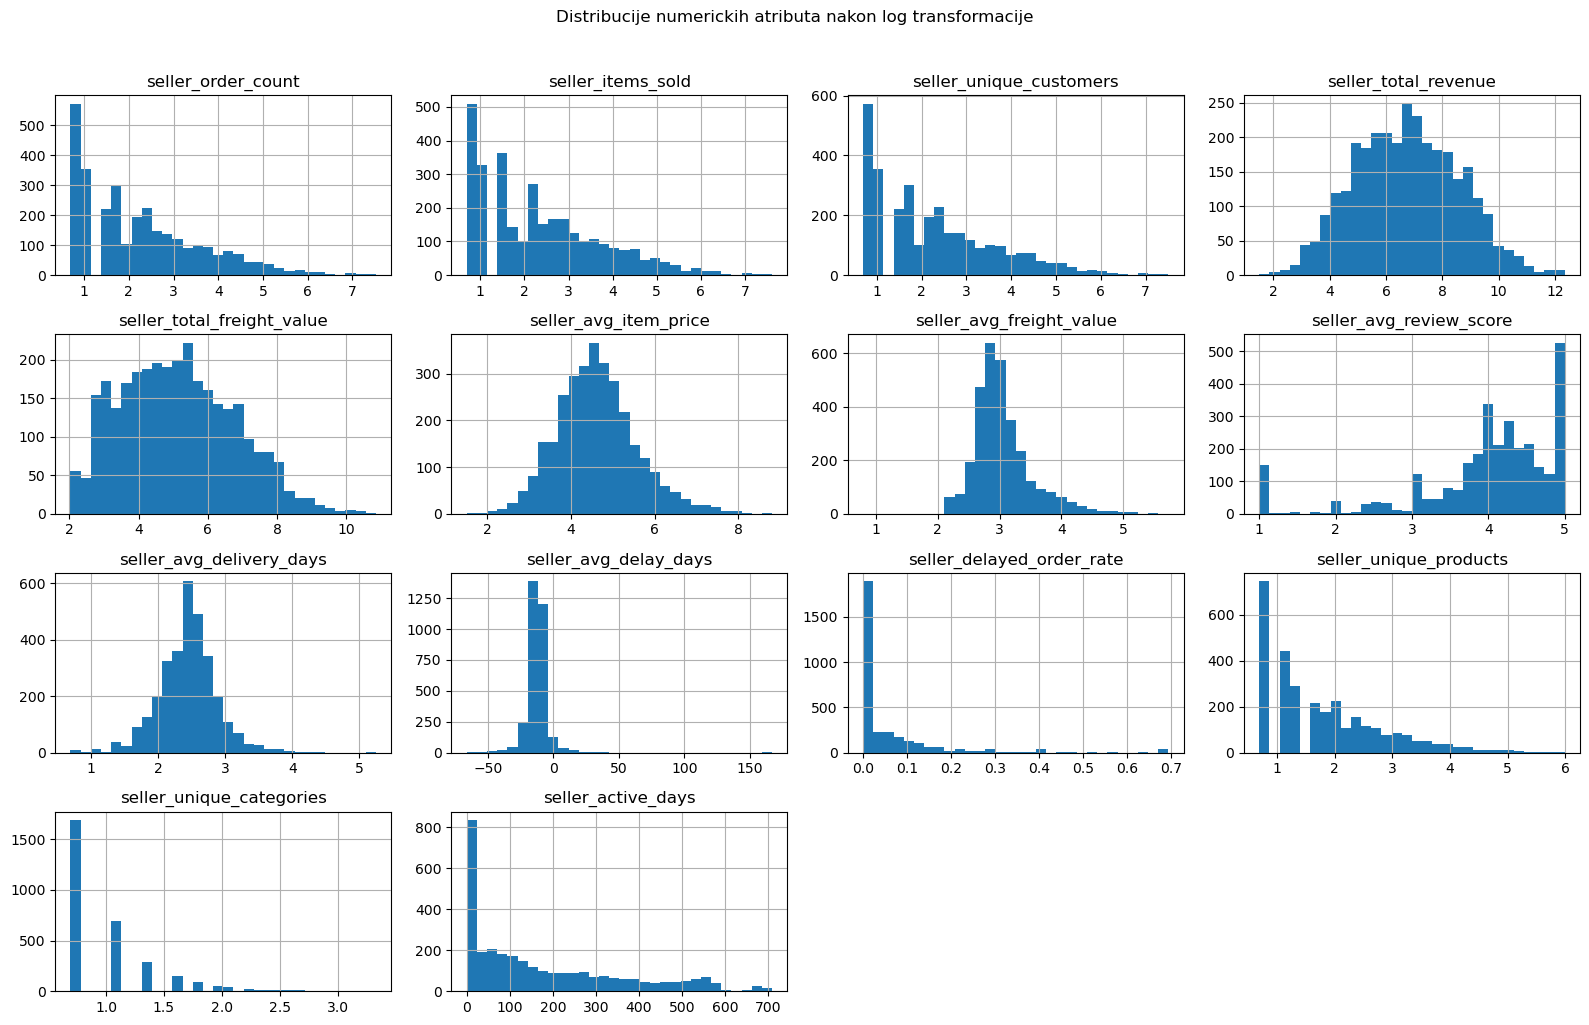

In [10]:
X_model.hist(
    figsize=(16, 10),
    bins=30
)

plt.suptitle("Distribucije numerickih atributa nakon log transformacije", y=1.02)
plt.tight_layout()
plt.show()

## Korelaciona analiza

Korelaciona matrica sluzi da se proveri odnos izmedju atributa. Kod prodavaca se ocekuje jaka povezanost izmedju broja porudzbina, broja prodatih artikala, broja kupaca i ukupnog prihoda.

Ova analiza ne sluzi za direktno izbacivanje atributa, vec za razumevanje strukture podataka pre PCA transformacije.

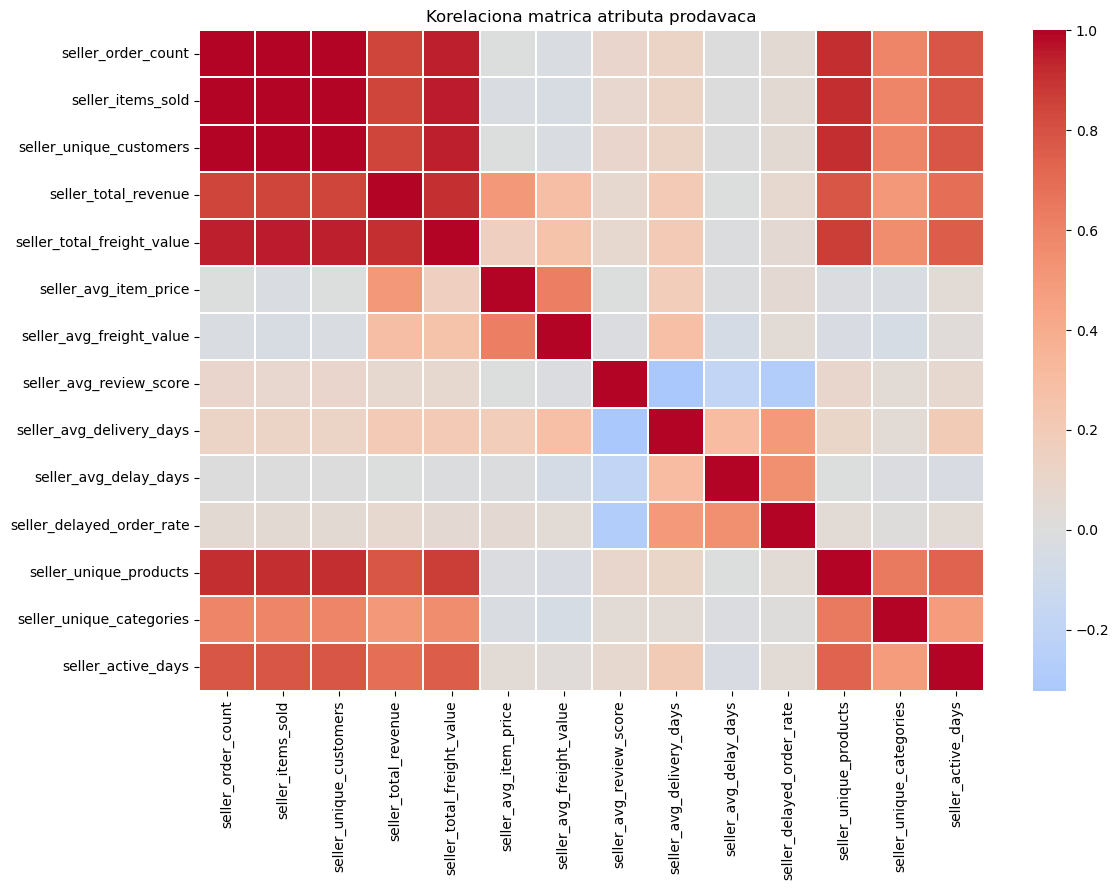

In [11]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    X_model.corr(),
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Korelaciona matrica atributa prodavaca")
plt.tight_layout()
plt.show()

## Skaliranje atributa

Posto atributi imaju razlicite jedinice mere i opsege vrednosti, pre klasterovanja se primenjuje standardizacija.

Standardizacija je obavezna u ovom slucaju, jer bi u suprotnom atributi sa vecim numerickim vrednostima, poput ukupnog prihoda, imali prevelik uticaj na formiranje klastera.

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_model)

X_scaled.shape

(3095, 14)

## PCA transformacija

PCA se koristi kako bi se smanjila dimenzionalnost prostora i uklonio deo redundantnosti iz korelisanih atributa.

Zadrzava se broj komponenti koji objasnjava najmanje 90% ukupne varijanse. To predstavlja kompromis izmedju ocuvanja informacija i jednostavnijeg prostora za klasterovanje.

Vazna metodoloska odluka u ovom notebooku je da se nakon PCA transformacije svi modeli i sve metrike racunaju nad istim prostorom `X_cluster`, odnosno nad PCA reprezentacijom `X_pca`. Na taj nacin su evaluacija, izbor modela i finalno dodeljivanje klastera potpuno dosledni.


In [13]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

n_components_90 = int(np.argmax(cumulative_variance >= 0.90) + 1)

print("Broj PCA komponenti za 90% varijanse:", n_components_90)

Broj PCA komponenti za 90% varijanse: 6


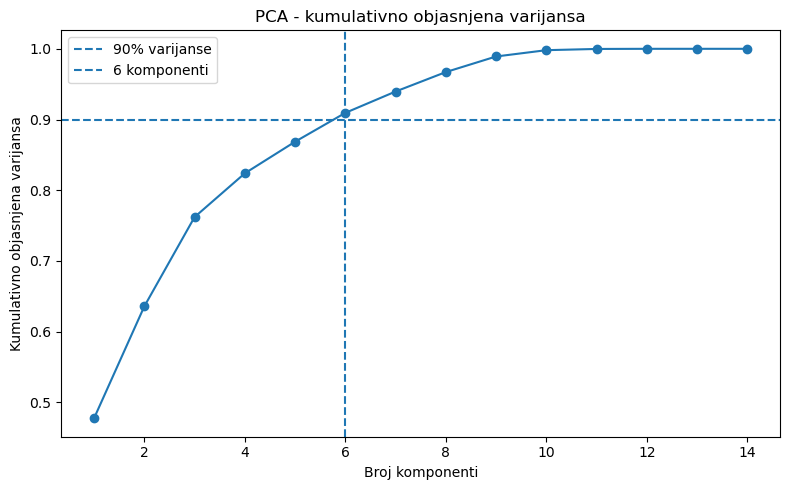

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.90,
    linestyle="--",
    label="90% varijanse"
)

plt.axvline(
    x=n_components_90,
    linestyle="--",
    label=f"{n_components_90} komponenti"
)

plt.xlabel("Broj komponenti")
plt.ylabel("Kumulativno objasnjena varijansa")
plt.title("PCA - kumulativno objasnjena varijansa")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
pca = PCA(
    n_components=n_components_90,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

# Prostor koji se koristi za treniranje, evaluaciju i finalno dodeljivanje klastera.
# Time se izbegava nedoslednost da se model evaluira nad jednim prostorom,
# a finalno trenira nad drugim.
X_cluster = X_pca

X_cluster.shape


(3095, 6)

##### Zašto je zadrzano 90% varijanse?

Prilikom primene PCA transformacije potrebno je izabrati broj komponenti koje ce biti sacuvane. Manji broj komponenti dovodi do veceg gubitka informacija, dok veci broj komponenti smanjuje efekat redukcije dimenzionalnosti.

U ovom radu zadržano je 90% ukupne objacnjene varijanse, cime se cuva najveci deo informacija sadržanih u originalnim atributima, uz istovremeno smanjenje dimenzionalnosti prostora za klasterovanje.

### Interpretacija glavnih komponenti

Nakon pripreme podataka primenjena je analiza glavnih komponenti (PCA) kako bi se smanjila dimenzionalnost skupa podataka uz zadržavanje najmanje 90% ukupne varijanse. Na ovaj način originalni skup atributa transformisan je u novi skup glavnih komponenti koje predstavljaju linearne kombinacije početnih atributa.

Radi lakše interpretacije prikazani su atributi sa najvećim apsolutnim opterećenjem za prve tri glavne komponente. Veća vrednost opterećenja ukazuje da dati atribut ima veći doprinos formiranju odgovarajuće komponente.

In [16]:
feature_names = X_model.columns

loadings = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)

for pc in loadings.index[:3]:

    top_features = (
        loadings.loc[pc]
        .abs()
        .sort_values(ascending=False)
        .head(5)
        .reset_index()
    )

    top_features.columns = ["Atribut", "Doprinos komponenti"]

    print(f"\n{pc}")
    display(
        top_features.style
        .format({"Doprinos komponenti": "{:.3f}"})
    )


PC1


,Atribut,Doprinos komponenti
0,seller_order_count,0.378
1,seller_unique_customers,0.378
2,seller_items_sold,0.377
3,seller_total_freight_value,0.374
4,seller_unique_products,0.360



PC2


,Atribut,Doprinos komponenti
0,seller_avg_delivery_days,0.503
1,seller_delayed_order_rate,0.479
2,seller_avg_delay_days,0.376
3,seller_avg_freight_value,0.343
4,seller_avg_item_price,0.336



PC3


,Atribut,Doprinos komponenti
0,seller_avg_item_price,0.552
1,seller_avg_freight_value,0.538
2,seller_avg_delay_days,0.381
3,seller_delayed_order_rate,0.334
4,seller_avg_review_score,0.228


Prva glavna komponenta najveci znacaj pridaje atributima koji opisuju obim poslovanja prodavca, kao sto su broj porudzbina, broj razlicitih kupaca, broj prodatih proizvoda i broj jedinstvenih proizvoda. Moze se zakljuciti da ova komponenta dominantno opisuje intenzitet poslovne aktivnosti prodavca.

Druga glavna komponenta prvenstveno zavisi od atributa koji opisuju proces isporuke, ukljucujuci prosecno vreme isporuke, stopu kasnjenja i prosecan broj dana kasnjenja. Zbog toga se moze interpretirati kao komponenta koja opisuje logisticke performanse prodavca.

Treca glavna komponenta najveci znacaj pridaje prosecnoj ceni proizvoda i troskovima dostave, dok u manjoj meri ukljucuje i ocene kupaca i stopu kasnjenja. Ova komponenta opisuje finansijske karakteristike prodaje i kvalitet usluge.

## Vizuelizacija podataka u dve PCA komponente

Prve dve PCA komponente koriste se samo za vizuelni prikaz. One ne moraju da sadrze sve informacije iz modela, ali mogu da pomognu u razumevanju da li postoje grupe, ekstremni prodavci ili kontinuirani prelazi izmedju prodavaca.

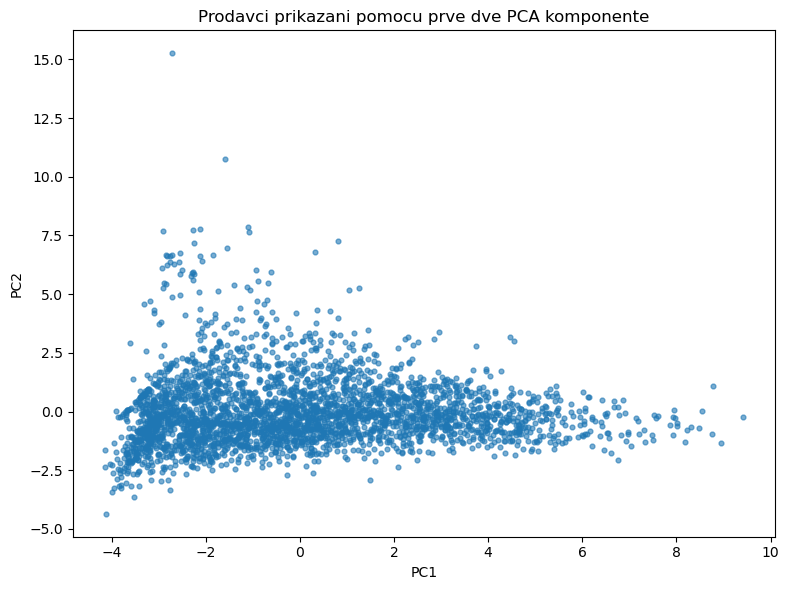

In [17]:
X_vis = PCA(
    n_components=2,
    random_state=42
).fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    s=12,
    alpha=0.6
)

plt.title("Prodavci prikazani pomocu prve dve PCA komponente")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# Agglomerative Clustering

Agglomerative Clustering je hijerarhijski algoritam koji pocinje tako sto svaku instancu posmatra kao poseban klaster, a zatim postepeno spaja najslicnije klastere.

U ovom notebooku se testiraju tri varijante povezivanja:

- `ward`
- `complete`
- `average`

Za svaki model se racunaju metrika kvaliteta i raspodela velicina klastera.

In [18]:
agg_results = []

for linkage_method in ["ward", "complete", "average"]:
    for k in range(2, 9):

        model = AgglomerativeClustering(
            n_clusters=k,
            linkage=linkage_method
        )

        labels = model.fit_predict(X_cluster)

        cluster_share = (
            pd.Series(labels)
            .value_counts(normalize=True)
            * 100
        )

        agg_results.append({
            "model": "Agglomerative",
            "linkage": linkage_method,
            "k": k,
            "silhouette_score": silhouette_score(X_cluster, labels),
            "davies_bouldin": davies_bouldin_score(X_cluster, labels),
            "calinski_harabasz": calinski_harabasz_score(X_cluster, labels),
            "min_cluster_pct": cluster_share.min(),
            "max_cluster_pct": cluster_share.max()
        })

agg_results = pd.DataFrame(agg_results)

agg_results.sort_values(
    by="silhouette_score",
    ascending=False
).round(4)


,model,linkage,k,silhouette_score,davies_bouldin,calinski_harabasz,min_cluster_pct,max_cluster_pct
7,Agglomerative,complete,2,0.7969,0.1436,40.5237,0.0323,99.9677
14,Agglomerative,average,2,0.7969,0.1436,40.5237,0.0323,99.9677
8,Agglomerative,complete,3,0.4473,0.6051,135.9272,0.0323,98.1906
15,Agglomerative,average,3,0.4341,0.6215,146.6264,0.0323,97.8998
9,Agglomerative,complete,4,0.3236,0.7662,726.8946,0.0323,70.9532
16,Agglomerative,average,4,0.3049,0.7013,100.6072,0.0323,97.8029
17,Agglomerative,average,5,0.2973,0.8011,79.0361,0.0323,97.8029
19,Agglomerative,average,7,0.2934,0.7752,389.3738,0.0323,66.6236
18,Agglomerative,average,6,0.2904,0.6956,63.6679,0.0323,97.8029
0,Agglomerative,ward,2,0.2595,1.3533,1271.9424,40.8078,59.1922


## Analiza rezultata Agglomerative modela

Kod hijerarhijskog klasterovanja nije dovoljno posmatrati samo `silhouette_score`. Visok rezultat moze nastati i kada algoritam izdvoji jedan veoma mali klaster ekstremnih prodavaca, dok svi ostali prodavci ostanu u jednoj velikoj grupi.

Zato se pored metrika posmatraju i kolone:

- `min_cluster_pct` - udeo najmanjeg klastera,
- `max_cluster_pct` - udeo najveceg klastera.

Model sa previse nebalansiranom raspodelom nije pogodan za poslovnu segmentaciju.

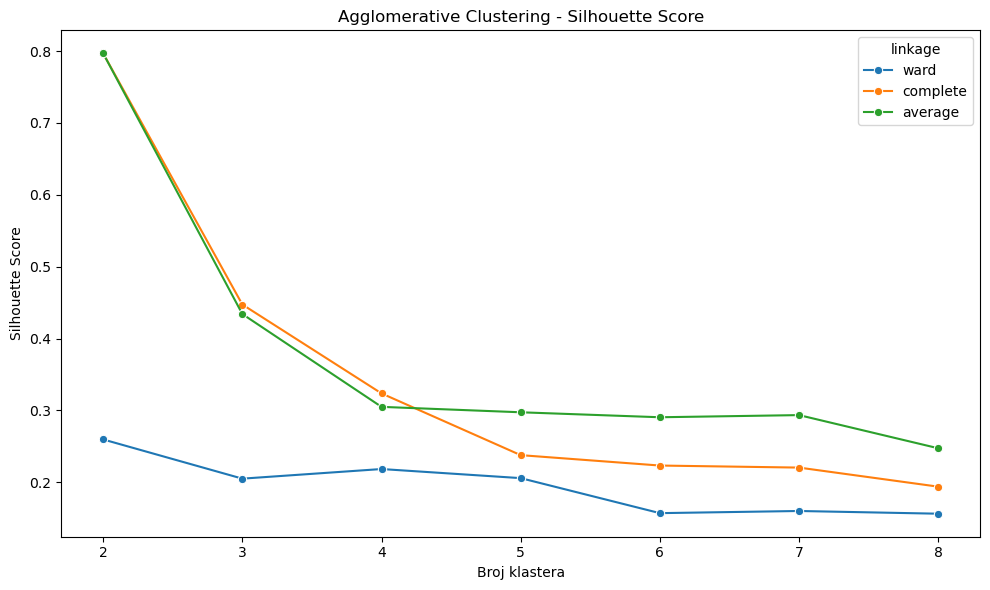

In [19]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=agg_results,
    x="k",
    y="silhouette_score",
    hue="linkage",
    marker="o"
)

plt.title("Agglomerative Clustering - Silhouette Score")
plt.xlabel("Broj klastera")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

## Dendrogram

Dendrogram prikazuje hijerarhijsku strukturu spajanja prodavaca. Zbog preglednosti se koristi uzorak prodavaca, jer bi dendrogram nad celim skupom bio previse gust za citanje.

Ovaj grafikon se ne koristi kao jedini kriterijum za izbor modela, vec kao dodatna vizuelna potvrda hijerarhijske strukture.

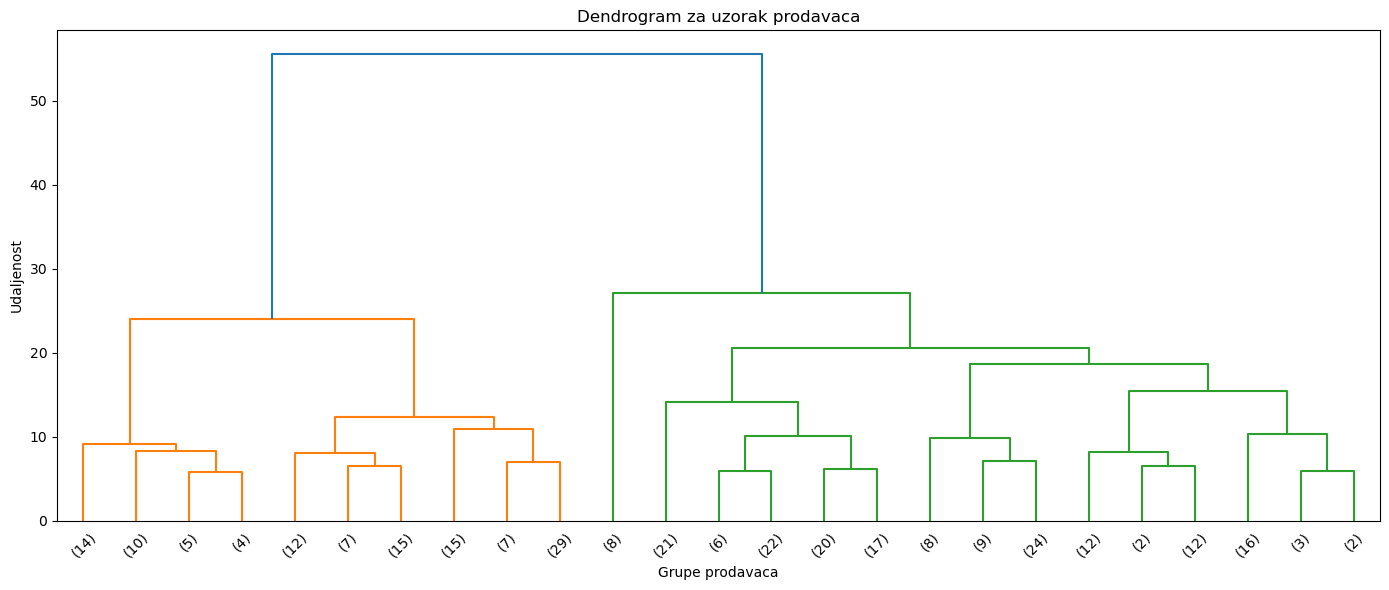

In [20]:
sample_size = min(300, X_cluster.shape[0])

rng = np.random.default_rng(42)
sample_idx = rng.choice(
    X_cluster.shape[0],
    size=sample_size,
    replace=False
)

Z = linkage(
    X_cluster[sample_idx],
    method="ward"
)

plt.figure(figsize=(14, 6))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=25
)

plt.title("Dendrogram za uzorak prodavaca")
plt.xlabel("Grupe prodavaca")
plt.ylabel("Udaljenost")
plt.tight_layout()
plt.show()


## Izbor broja klastera

Najvece vrednosti Silhouette Score metrike ostvarene su za resenja sa dva i tri klastera. Medjutim, analiza raspodele instanci pokazala je da se u tim slucajevima vise od 98% prodavaca nalazi u jednom klasteru, dok preostali klasteri sadrze veoma mali broj instanci.

Takva resenja nisu pogodna za segmentaciju prodavaca jer zapravo izdvajaju manji broj anomalnih slucajeva umesto formiranja smislenih grupa sa jasnim karakteristikama.

Zbog toga izbor modela nije zasnovan iskljucivo na vrednosti Silhouette Score metrike. Pored kvaliteta klasterovanja analizirani su i raspodela klastera, mogucnost interpretacije rezultata i vizuelna separacija grupa.

Na osnovu svih kriterijuma izabrano je resenje sa Ward povezivanjem i cetiri klastera. Iako ostvaruje nizu vrednost Silhouette Score metrike od najjednostavnijih resenja, ovo resenje daje znatno uravnotezenije klastere i omogucava smisleniju segmentaciju prodavaca.


In [21]:
final_agg_model = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

final_agg_labels = final_agg_model.fit_predict(
    X_cluster
)

seller_master["agg_cluster"] = final_agg_labels


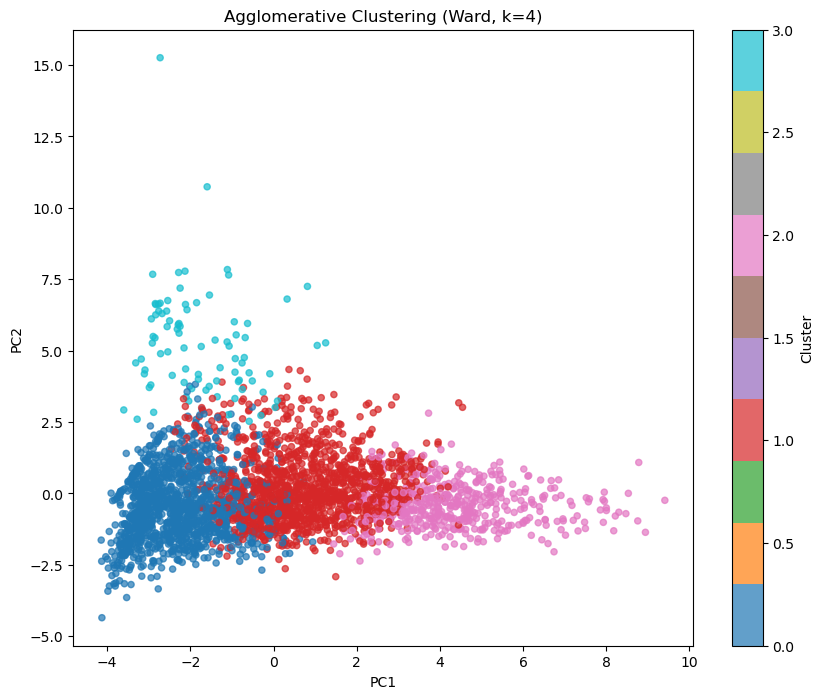

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_vis = PCA(
    n_components=2,
    random_state=42
).fit_transform(X_scaled)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=final_agg_labels,
    cmap="tab10",
    s=20,
    alpha=0.7
)

plt.title("Agglomerative Clustering (Ward, k=4)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.show()

# Gaussian Mixture Model

Gaussian Mixture Model je probabilisticki algoritam klasterovanja. Za razliku od algoritama koji svaku instancu strogo dodeljuju jednom klasteru, GMM modeluje podatke kao mesavinu vise normalnih raspodela.

Ovaj pristup je koristan kada granice izmedju grupa nisu potpuno ostre, sto je cesto slucaj kod prodavaca koji se mogu postepeno razlikovati po aktivnosti, prihodu i kvalitetu usluge.

In [23]:
gmm_results = []

for covariance_type in ["full", "diag"]:
    for k in range(2, 9):

        model = GaussianMixture(
            n_components=k,
            covariance_type=covariance_type,
            random_state=42,
            n_init=2,
            max_iter=100,
            init_params="k-means++"
        )

        labels = model.fit_predict(X_cluster)

        cluster_share = (
            pd.Series(labels)
            .value_counts(normalize=True)
            * 100
        )

        gmm_results.append({
            "model": "GMM",
            "covariance_type": covariance_type,
            "k": k,
            "silhouette_score": silhouette_score(X_cluster, labels),
            "davies_bouldin": davies_bouldin_score(X_cluster, labels),
            "calinski_harabasz": calinski_harabasz_score(X_cluster, labels),
            "aic": model.aic(X_cluster),
            "bic": model.bic(X_cluster),
            "min_cluster_pct": cluster_share.min(),
            "max_cluster_pct": cluster_share.max()
        })

gmm_results = pd.DataFrame(gmm_results)

gmm_results.sort_values(
    by="silhouette_score",
    ascending=False
).round(4)


,model,covariance_type,k,silhouette_score,davies_bouldin,calinski_harabasz,aic,bic,min_cluster_pct,max_cluster_pct
8,GMM,diag,3,0.2542,1.6190,939.3745,55623.5212,55852.9478,14.0872,52.8918
1,GMM,full,3,0.2042,1.9228,815.5024,48963.0645,49464.1806,17.0275,48.6268
0,GMM,full,2,0.2007,1.7867,707.0979,53764.4478,54096.5127,30.0808,69.9192
7,GMM,diag,2,0.1935,2.1529,464.5614,56392.8578,56543.7963,24.3619,75.6381
11,GMM,diag,6,0.1913,1.4757,790.7448,53840.8908,54305.7816,3.9418,28.0452
9,GMM,diag,4,0.1470,1.8952,598.9959,54843.5523,55151.4670,12.2779,51.9225
12,GMM,diag,7,0.1229,1.8442,607.0645,53178.4586,53721.8375,5.6543,25.6220
10,GMM,diag,5,0.1180,1.8871,603.2592,54353.4553,54739.8580,5.6220,35.3796
2,GMM,full,4,0.1179,2.2056,577.5002,42260.4148,42930.5821,9.2084,43.8126
13,GMM,diag,8,0.1102,1.7615,637.8244,52813.7856,53435.6526,3.0372,20.3231


## AIC i BIC kod GMM modela

Za GMM se pored klasicnih metrika klasterovanja koriste i AIC i BIC. Ove metrike mere kvalitet probabilistickog modela uz kaznu za slozenost.

Niza vrednost AIC/BIC ukazuje na bolji model, ali se i ovde mora voditi racuna o poslovnoj interpretaciji i raspodeli velicina klastera.

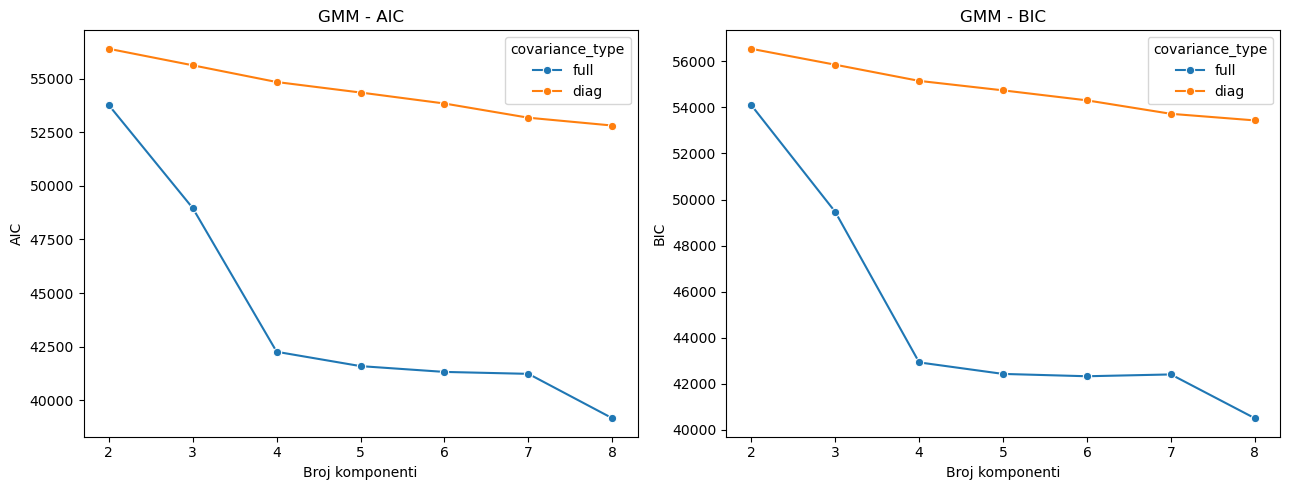

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for metric, ax in zip(["aic", "bic"], axes):
    sns.lineplot(
        data=gmm_results,
        x="k",
        y=metric,
        hue="covariance_type",
        marker="o",
        ax=ax
    )

    ax.set_title(f"GMM - {metric.upper()}")
    ax.set_xlabel("Broj komponenti")
    ax.set_ylabel(metric.upper())

plt.tight_layout()
plt.show()

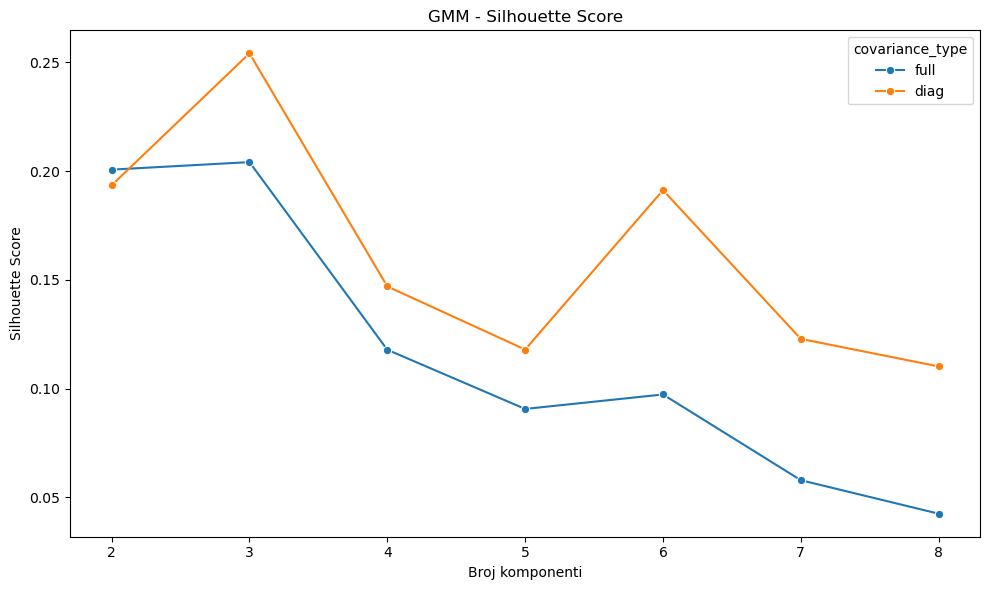

In [25]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=gmm_results,
    x="k",
    y="silhouette_score",
    hue="covariance_type",
    marker="o"
)

plt.title("GMM - Silhouette Score")
plt.xlabel("Broj komponenti")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

## Izbor broja klastera

Za izbor optimalnog GMM modela analizirane su Silhouette Score, AIC i BIC metrike.

Najnize vrednosti AIC i BIC kriterijuma ostvarene su za modele sa vecim brojem komponenti. Medjutim, kontinuirano opadanje ovih kriterijuma ukazuje da bi izbor iskljucivo na osnovu njih doveo do nepotrebno slozenih modela sa velikim brojem klastera.

Sa druge strane, najveci Silhouette Score ostvaren je za model sa dijagonalnom kovarijacionom matricom i tri klastera. Pored toga, raspodela instanci po klasterima bila je relativno uravnotezena, bez dominacije jednog klastera.

Zbog toga je za dalju analizu izabran GMM model sa tri klastera i dijagonalnom kovarijacionom matricom.

In [26]:
final_gmm = GaussianMixture(
    n_components=3,
    covariance_type="diag",
    random_state=42,
    n_init=2,
    max_iter=100,
    init_params="k-means++"
)

final_gmm_labels = final_gmm.fit_predict(X_cluster)

seller_master["gmm_cluster"] = final_gmm_labels


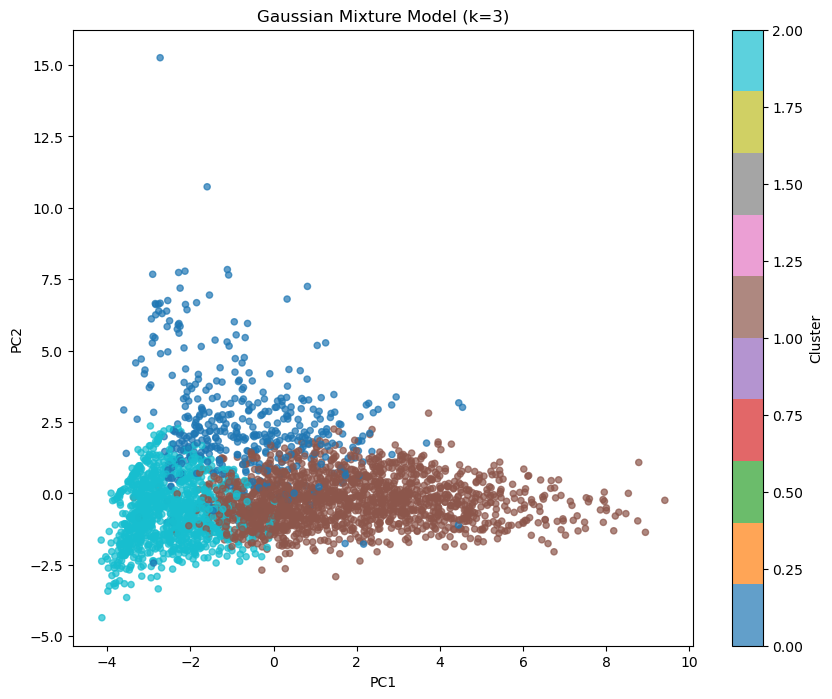

In [27]:
X_vis = PCA(
    n_components=2,
    random_state=42
).fit_transform(X_scaled)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=final_gmm_labels,
    cmap="tab10",
    s=20,
    alpha=0.7
)

plt.title("Gaussian Mixture Model (k=3)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.show()

In [28]:
final_model_comparison = pd.DataFrame([
    {
        "model": "Agglomerative",
        "configuration": "ward, k=4",
        "silhouette_score": silhouette_score(X_cluster, final_agg_labels),
        "davies_bouldin": davies_bouldin_score(X_cluster, final_agg_labels),
        "calinski_harabasz": calinski_harabasz_score(X_cluster, final_agg_labels),
        "min_cluster_pct": pd.Series(final_agg_labels).value_counts(normalize=True).min() * 100,
        "max_cluster_pct": pd.Series(final_agg_labels).value_counts(normalize=True).max() * 100
    },
    {
        "model": "GMM",
        "configuration": "diag, k=3",
        "silhouette_score": silhouette_score(X_cluster, final_gmm_labels),
        "davies_bouldin": davies_bouldin_score(X_cluster, final_gmm_labels),
        "calinski_harabasz": calinski_harabasz_score(X_cluster, final_gmm_labels),
        "min_cluster_pct": pd.Series(final_gmm_labels).value_counts(normalize=True).min() * 100,
        "max_cluster_pct": pd.Series(final_gmm_labels).value_counts(normalize=True).max() * 100
    }
])

final_model_comparison.round(4)


,model,configuration,silhouette_score,davies_bouldin,calinski_harabasz,min_cluster_pct,max_cluster_pct
0,Agglomerative,"ward, k=4",0.2183,1.2599,1046.1835,2.7787,41.6478
1,GMM,"diag, k=3",0.2542,1.6190,939.3745,14.0872,52.8918


## Poredjenje algoritama

Nakon izbora najboljih konfiguracija za oba algoritma izvrseno je njihovo poredjenje na osnovu metrika kvaliteta, raspodele velicina klastera i vizuelne analize.

GMM model sa tri klastera ostvaruje bolji odnos izmedju kvaliteta klasterovanja i jednostavnosti interpretacije. Vizuelizacija u PCA prostoru pokazuje da GMM formira tri jasnije definisane grupe prodavaca bez dodatnog razdvajanja centralne grupe.

Sa druge strane, Agglomerative algoritam identifikuje slicnu strukturu podataka, ali deli centralni segment na dva manja klastera. Iako takva segmentacija moze biti korisna u pojedinim situacijama, dodatni klaster nije dovoljno jasno izdvojen da bi opravdao slozeniji model.

**Zbog toga je kao finalni model za segmentaciju prodavaca izabran Gaussian Mixture Model sa tri klastera i dijagonalnom kovarijacionom matricom.**


## Profilisanje klastera

Nakon izbora finalnog GMM modela, sledeci korak predstavlja analiza karakteristika svakog klastera.

Cilj ovog koraka nije samo identifikacija grupa prodavaca, vec i razumevanje njihovog poslovnog ponasanja. Zbog toga se klasteri profilisu nad originalnim vrednostima atributa, a ne nad skaliranim, log-transformisanim ili PCA transformisanim vrednostima.

Na taj nacin se model trenira u prostoru pogodnom za klasterovanje, dok se interpretacija radi u prostoru koji ima jasno poslovno znacenje.


In [29]:
seller_master["cluster"] = final_gmm_labels

In [30]:
cluster_profile = (
    seller_master
    .groupby("cluster")
    .agg(
        seller_order_count=("seller_order_count", "mean"),
        seller_items_sold=("seller_items_sold", "mean"),
        seller_total_revenue=("seller_total_revenue", "mean"),
        seller_avg_freight_value=("seller_avg_freight_value", "mean"),
        seller_avg_review_score=("seller_avg_review_score", "mean"),
        seller_avg_delivery_days=("seller_avg_delivery_days", "mean"),
        seller_avg_delay_days=("seller_avg_delay_days", "mean"),
        seller_delayed_order_rate=("seller_delayed_order_rate", "mean"),
        seller_unique_categories=("seller_unique_categories", "mean")
    )
    .round(2)
)

cluster_profile

,seller_order_count,seller_items_sold,seller_total_revenue,seller_avg_freight_value,seller_avg_review_score,seller_avg_delivery_days,seller_avg_delay_days,seller_delayed_order_rate,seller_unique_categories
cluster,,,,,,,,,
0,5.85,6.66,3036.02,47.15,3.48,19.05,-7.30,0.24,1.48
1,58.19,65.46,7345.22,20.44,4.15,11.24,-12.63,0.05,2.91
2,2.15,2.53,238.57,17.95,3.90,9.19,-13.83,0.00,1.18


In [31]:
cluster_profile_scaled = pd.DataFrame(
    StandardScaler().fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

cluster_profile_scaled.round(2)

,seller_order_count,seller_items_sold,seller_total_revenue,seller_avg_freight_value,seller_avg_review_score,seller_avg_delivery_days,seller_avg_delay_days,seller_delayed_order_rate,seller_unique_categories
cluster,,,,,,,,,
0,-0.63,-0.63,-0.17,1.41,-1.31,1.39,1.39,1.39,-0.5
1,1.41,1.41,1.30,-0.61,1.11,-0.45,-0.49,-0.45,1.4
2,-0.78,-0.78,-1.13,-0.80,0.20,-0.93,-0.91,-0.93,-0.9


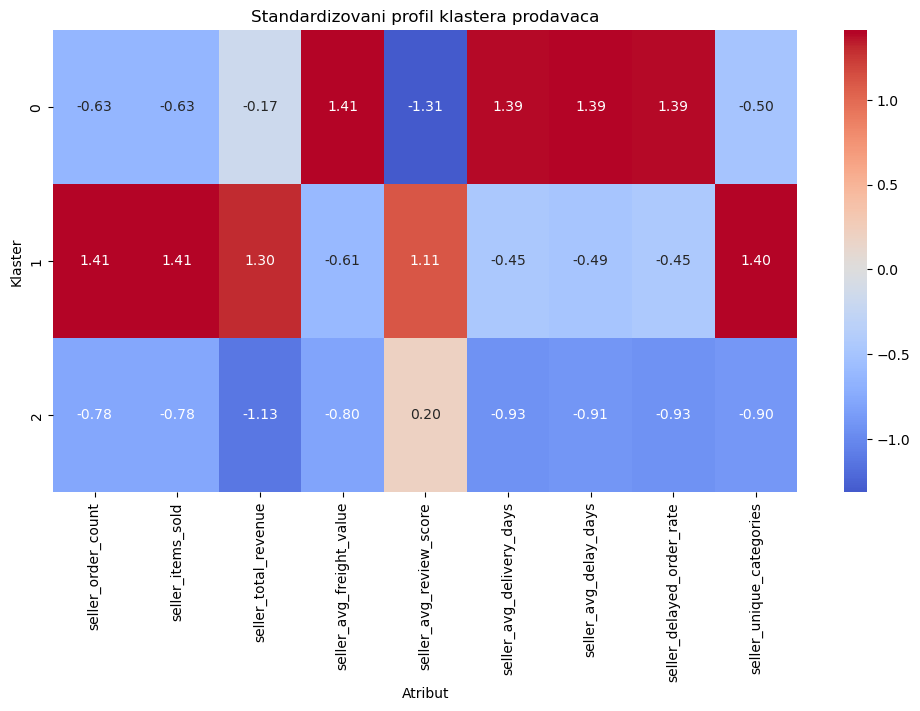

In [32]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    cluster_profile_scaled,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Standardizovani profil klastera prodavaca")
plt.xlabel("Atribut")
plt.ylabel("Klaster")

plt.show()

## Interpretacija seller klastera

- **Klaster 0 – Mali pouzdani prodavci** obuhvata prodavce sa manjim brojem porudžbina, manjim brojem prodatih proizvoda i nižim ukupnim prihodom. Uprkos tome, ostvaruju više ocene kupaca, kraće vreme isporuke i manju stopu kašnjenja od proseka. Ovaj segment predstavlja manje prodavce koji se izdvajaju kvalitetom usluge i efikasnom logistikom.

- **Klaster 1 – Vodeći prodavci** čine najveći i najuspešniji prodavci na platformi. Oni ostvaruju najveći broj porudžbina, prodaju najveći broj proizvoda i generišu najveći prihod. Posluju u većem broju kategorija proizvoda i imaju iznadprosečne ocene kupaca. Ovaj segment predstavlja ključne nosioce prodaje na platformi.

- **Klaster 2 – Prodavci sa prostorom za unapređenje** obuhvata prodavce sa najmanjim obimom poslovanja i najnižim prihodima. Karakterišu ih niže ocene kupaca, duže vreme isporuke i veća stopa kašnjenja. Ovaj segment ukazuje na potrebu za unapređenjem logističkih procesa i korisničkog iskustva.

### Udeo ukupnog prihoda po klasterima

In [33]:
cluster_share = (
    seller_master["cluster"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

revenue_share = (
    seller_master
    .groupby("cluster")["seller_total_revenue"]
    .sum()
)

revenue_share = (
    revenue_share
    / revenue_share.sum()
    * 100
)

comparison = pd.DataFrame({
    "Seller Share (%)": cluster_share,
    "Revenue Share (%)": revenue_share
})

comparison

,Seller Share (%),Revenue Share (%)
cluster,,
0,14.087237,9.739097
1,52.891761,88.467007
2,33.021002,1.793895


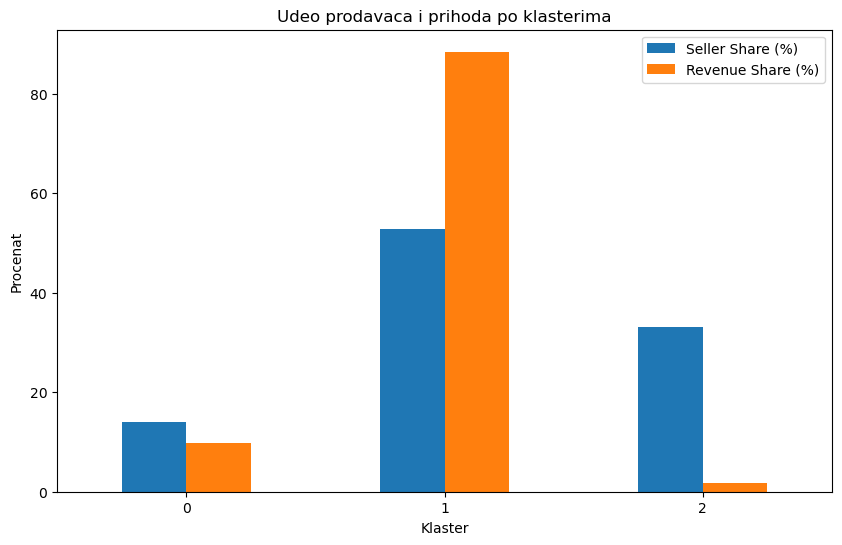

In [34]:
comparison.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Udeo prodavaca i prihoda po klasterima"
)

plt.xlabel("Klaster")
plt.ylabel("Procenat")

plt.xticks(rotation=0)

plt.show()

## Analiza kategorija proizvoda

Pored poslovnih performansi, analizirane su i najzastupljenije kategorije proizvoda u svakom klasteru. Cilj ove analize je da se utvrdi da li se izdvojeni segmenti prodavaca razlikuju samo po obimu poslovanja ili i po tipu proizvoda koje prodaju.

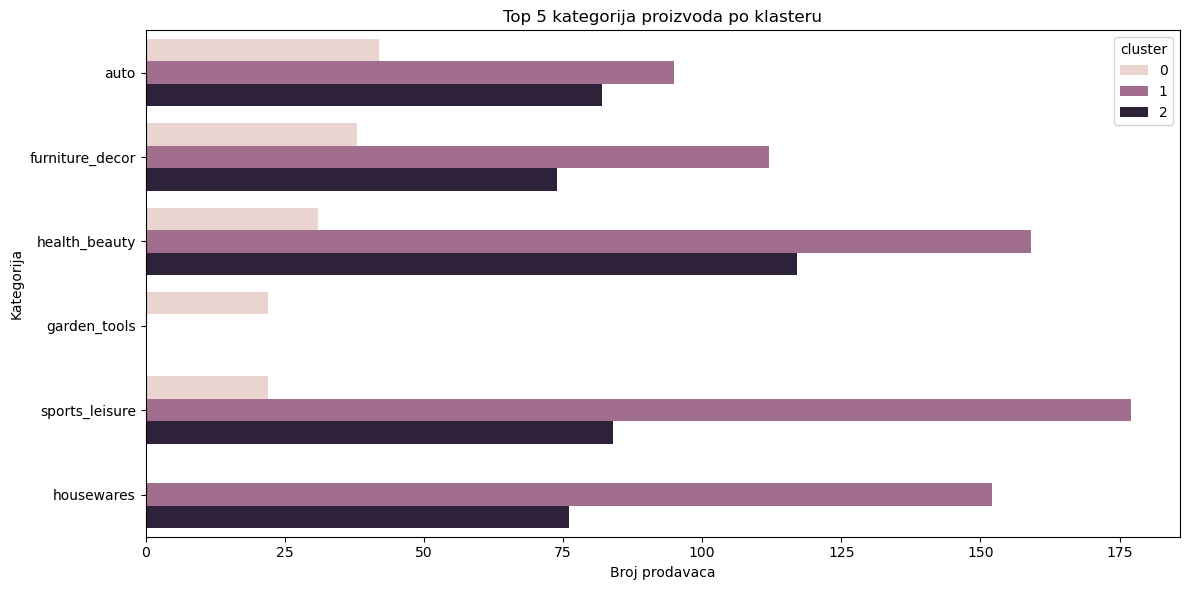

In [35]:
top_categories = (
    seller_master
    .groupby("cluster")["seller_top_category"]
    .value_counts()
    .groupby(level=0)
    .head(5)
    .reset_index(name="count")
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_categories,
    x="count",
    y="seller_top_category",
    hue="cluster"
)

plt.title("Top 5 kategorija proizvoda po klasteru")
plt.xlabel("Broj prodavaca")
plt.ylabel("Kategorija")

plt.tight_layout()
plt.show()

## Analiza geografske raspodele prodavaca

Nakon analize kategorija proizvoda, ispitana je i geografska raspodela prodavaca. Posmatrana je zastupljenost prodavaca po brazilskim državama kako bi se utvrdilo da li pojedini segmenti pokazuju regionalne specifičnosti.

Ova analiza omogućava dodatno razumevanje strukture tržišta i potencijalnih geografskih obrazaca u poslovanju prodavaca.

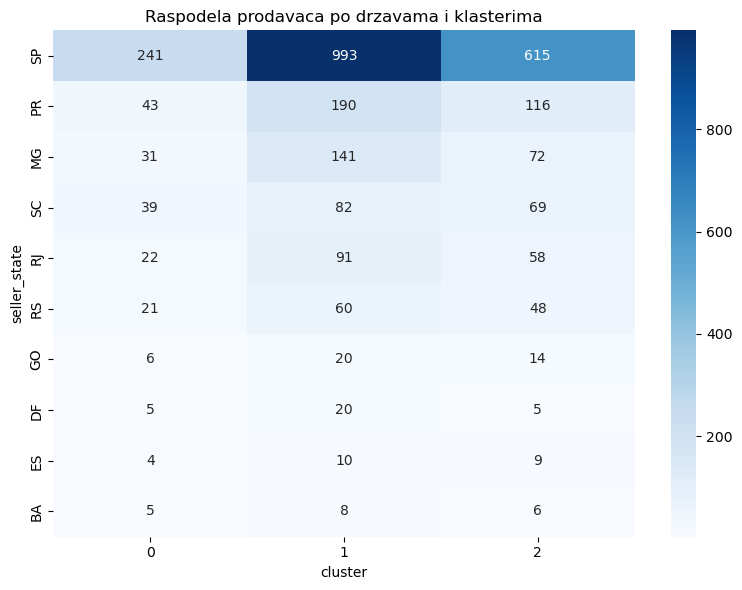

In [36]:
state_cluster = pd.crosstab(
    seller_master["seller_state"],
    seller_master["cluster"]
)

top_states = (
    seller_master["seller_state"]
    .value_counts()
    .head(10)
    .index
)

plt.figure(figsize=(8,6))

sns.heatmap(
    state_cluster.loc[top_states],
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Raspodela prodavaca po drzavama i klasterima")

plt.tight_layout()
plt.show()

Analiza kategorija proizvoda pokazuje da su najzastupljenije kategorije uglavnom slicne u svim klasterima, sto ukazuje da se prodavci ne razlikuju znacajno po vrsti proizvoda koje prodaju. Ipak, klaster 2 ima izrazenije prisustvo kategorija *health_beauty*, *auto* i *furniture_decor*, sto dodatno naglasava njegov veci obim poslovanja i raznovrsniju ponudu.

Geografska analiza pokazuje da su svi klasteri dominantno zastupljeni u drzavi Sao Paulo (SP), dok se iza nje izdvajaju Parana (PR), Minas Gerais (MG) i Santa Catarina (SC). Slicna geografska raspodela u svim klasterima ukazuje da lokacija prodavca nije glavni faktor koji utice na formiranje segmenata.

**Na osnovu ovih rezultata moze se zakljuciti da su klasteri prvenstveno formirani na osnovu poslovnih performansi, kao sto su broj porudzbina, prihod, ocene kupaca i logisticka efikasnost, dok kategorija proizvoda i geografska lokacija imaju manji uticaj na njihovo razdvajanje.**

# Zakljucak

U ovom notebooku je izvrsena segmentacija prodavaca pomocu dva razlicita pristupa: hijerarhijskog klasterovanja i GMM modela. Pre klasterovanja su izdvojeni numericki atributi, primenjena je log transformacija nad izrazito asimetricnim promenljivama, zatim standardizacija i PCA transformacija.

Rezultati pokazuju da se prodavci najvise razlikuju prema obimu poslovanja, ukupnom prihodu, broju kupaca, raznovrsnosti proizvoda i logistickim performansama. Zbog toga se klasteri mogu tumaciti kao razliciti tipovi prodavaca: od manjih i manje aktivnih prodavaca, preko stabilnih prodavaca, do visoko aktivnih prodavaca koji imaju najveci poslovni znacaj za platformu.

Posebno je vazno sto se profilisanje klastera radi nad originalnim vrednostima, a ne nad skaliranim, log-transformisanim ili PCA transformisanim podacima. Na taj nacin klasteri ostaju poslovno interpretabilni.

Ova analiza dopunjuje prethodnu segmentaciju kupaca i zajedno sa njom daje siru sliku Olist platforme: ko su kupci, kakvi su prodavci i koje karakteristike najvise doprinose performansama platforme.
